In [1]:
!wget https://storage.googleapis.com/questionsanswersproject/sounds-classification/sounds-classification-export.zip

--2026-04-18 22:29:35--  https://storage.googleapis.com/questionsanswersproject/sounds-classification/sounds-classification-export.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 172.217.194.207, 172.217.70.207, 172.253.134.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.217.194.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8038438 (7.7M) [application/zip]
Saving to: ‘sounds-classification-export.zip’

sounds-classificati 100%[===================>]   7.67M  2.63MB/s    in 2.9s    

2026-04-18 22:29:38 (2.63 MB/s) - ‘sounds-classification-export.zip’ saved [8038438/8038438]



In [2]:
!mkdir sounds-classification-export
!cp sounds-classification-export.zip sounds-classification-export/
!rm sounds-classification-export.zip
%cd sounds-classification-export
!unzip sounds-classification-export.zip
!rm sounds-classification-export.zip

/content/sounds-classification-export
Archive:  sounds-classification-export.zip
  inflating: README.txt              
  inflating: info.labels             
   creating: testing/
  inflating: testing/chair.6mbeuaaf.ingestion-75b48c5d57-9kfhp.s1.wav  
  inflating: testing/chair.6mbeuaaf.ingestion-75b48c5d57-9kfhp.s2.wav  
  inflating: testing/chair.6mbeuaaf.ingestion-75b48c5d57-9kfhp.s3.wav  
  inflating: testing/chair.6mbeuaaf.ingestion-75b48c5d57-9kfhp.s4.wav  
  inflating: testing/chair.6mbeuaaf.ingestion-75b48c5d57-9kfhp.s5.wav  
  inflating: testing/chair.6mbeuaaf.ingestion-75b48c5d57-9kfhp.s6.wav  
  inflating: testing/chair.6mbeuaaf.ingestion-75b48c5d57-9kfhp.s7.wav  
  inflating: testing/chair.6mbeuaaf.ingestion-75b48c5d57-9kfhp.s8.wav  
  inflating: testing/chair.6mbeuaaf.ingestion-75b48c5d57-9kfhp.s9.wav  
  inflating: testing/chair.6mbeur2g.ingestion-75b48c5d57-ffldf.s1.wav  
  inflating: testing/chair.6mbeur2g.ingestion-75b48c5d57-ffldf.s10.wav  
  inflating: testing/chair.6

## **Installing Libraries**

In [3]:
!pip install rich

In [4]:
!pip install --upgrade keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 76.9 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.13.2
    Uninstalling keras-3.13.2:
      Successfully uninstalled keras-3.13.2


## **Imports**

In [5]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import tensorflow as tf
from keras import layers, Model
import tensorflow as tf

print(f"Versión de Keras: {keras.__version__}")

Versión de Keras: 3.14.0


In [6]:
import tensorflow as tf
import numpy as np
import os
import time
from IPython import display as ipythondisplay
from tqdm import tqdm
from rich.console import Console
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython import display

console = Console()

## **Dataset Exploration**

In [7]:
def load_wav_16k_mono(filename):
    # Load encoded wav file
    file_contents = tf.io.read_file(filename)
    # Decode wav (tensors by channels)
    wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
    # Removes trailing axis
    wav = tf.squeeze(wav, axis=-1)
   # sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    # Goes from 44100Hz to 16000hz - amplitude of the audio signal
   # wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
    return wav

(16000,)

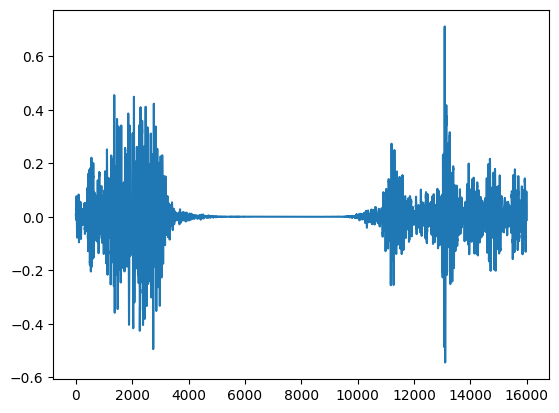

In [8]:
# Ejemplo de carga de un archivo
example_file="/content/sounds-classification-export/testing/chair.6mbeuaaf.ingestion-75b48c5d57-9kfhp.s1.wav"
wave = load_wav_16k_mono(example_file)
console.print(wave.shape)
plt.plot(wave)
plt.show()

In [9]:
def preprocess(wave):
    # Ensure all waves are exactly 16000 samples long. Pad if shorter, truncate if longer.
    max_len = 16000
    if tf.shape(wave)[0] < max_len:
        # Pad with zeros at the end
        padding = max_len - tf.shape(wave)[0]
        wav = tf.pad(wave, [[0, padding]], "CONSTANT")
    else:
        wav = wave[:max_len]

    spectrogram = tf.signal.stft(wav, frame_length=255, frame_step=128)
    spectrogram = tf.abs(spectrogram)
    return spectrogram

In [10]:
espectrograma= preprocess(wave)
console.print('Waveform shape:', wave.shape)
console.print('Spectrogram shape:', espectrograma.shape)
console.print('Audio playback')
display.display(display.Audio(wave, rate=16000))

Waveform shape: (16000,)

Spectrogram shape: (124, 129)

Audio playback

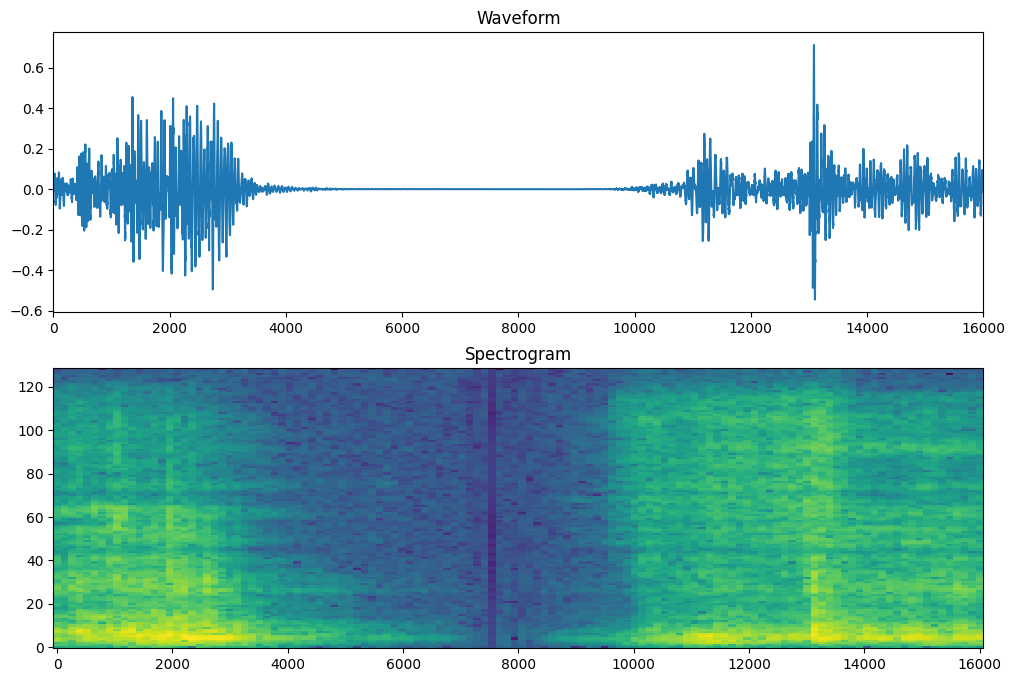

In [11]:
def plot_spectrogram(espectrograma, ax):
  # Convert to frequencies to log scale and transpose so that the time is
  # represented in the x-axis (columns).
  log_spec = np.log(espectrograma.T)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(espectrograma), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)


fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(wave.shape[0])
axes[0].plot(timescale, wave.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 16000])
plot_spectrogram(espectrograma.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.show()

## **Create Datasets**

In [12]:
import os

directory = '/content/sounds-classification-export/training/'
files = os.listdir(directory)
files.sort()

wav_files = [f for f in files if f.endswith('.wav')]
number_files = len(wav_files)
console.print(number_files)

spectrogram_audios=np.zeros((number_files, 124, 129))

for index, file_name in enumerate(wav_files):
  file_path=directory + file_name
  wave = load_wav_16k_mono(file_path)
  spectrogram= preprocess(wave)
  spectrogram_audios[index,:,:]=spectrogram

x_train=tf.expand_dims(spectrogram_audios, axis=3)

console.print(spectrogram_audios.shape)
console.print(x_train.shape)

256

(256, 124, 129)

(256, 124, 129, 1)

In [13]:
y_train_ini=np.zeros((256,1))

for index, file_name in enumerate(wav_files):
  class_file = file_name.split('.')[0]
  if class_file == 'chair':
    y_train_ini[index]=0
  if class_file == 'door':
    y_train_ini[index]=1
  if class_file == 'voice':
    y_train_ini[index]=2
  if class_file == 'water':
    y_train_ini[index]=3

console.print(y_train_ini.shape)

(256, 1)

In [14]:
# one hot encoding
y_train = keras.utils.to_categorical(y_train_ini)
console.print(y_train)

[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 ...
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]

In [56]:
full_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
full_dataset = full_dataset.shuffle(buffer_size=256)

size = x_train.shape[0]

val_size = int(0.2 * size)
train_size = size - val_size

train_ds = full_dataset.take(train_size).batch(32)
val_ds = full_dataset.skip(train_size).batch(32)

In [57]:
import os

directory = '/content/sounds-classification-export/testing/'
files = os.listdir(directory)
files.sort()

wav_files = [f for f in files if f.endswith('.wav')]
number_files = len(wav_files)
console.print(number_files)

spectrogram_audios=np.zeros((number_files, 124, 129))

for index, file_name in enumerate(wav_files):
  file_path=directory + file_name
  wave = load_wav_16k_mono(file_path)
  spectrogram= preprocess(wave)
  spectrogram_audios[index,:,:]=spectrogram

x_val=tf.expand_dims(spectrogram_audios, axis=3)

console.print(spectrogram_audios.shape)
console.print(x_val.shape)

85

(85, 124, 129)

(85, 124, 129, 1)

In [58]:
y_val_ini=np.zeros((85,1))

for index, file_name in enumerate(wav_files):
  class_file = file_name.split('.')[0]
  if class_file == 'chair':
    y_val_ini[index]=0
  if class_file == 'door':
    y_val_ini[index]=1
  if class_file == 'voice':
    y_val_ini[index]=2
  if class_file == 'water':
    y_val_ini[index]=3

console.print(y_val_ini.shape)

y_val = keras.utils.to_categorical(y_val_ini)
console.print(y_val)


(85, 1)

[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]

In [59]:
console.print("Training data class distribution:")
for i in range(4):
    count = np.sum(y_train_ini == i)
    console.print(f"Class {i}: {count} samples")

console.print("\nValidation data class distribution:")
for i in range(4):
    count = np.sum(y_val_ini == i)
    console.print(f"Class {i}: {count} samples")

Training data class distribution:

Class 0: 63 samples

Class 1: 65 samples

Class 2: 60 samples

Class 3: 68 samples

Validation data class distribution:

Class 0: 20 samples

Class 1: 21 samples

Class 2: 21 samples

Class 3: 23 samples

## **Convolutional Neural Network**

In [60]:
data_augmentation = keras.Sequential([
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1), # Time and Frequency Shifting
    layers.RandomContrast(factor=0.1), # Noise Injection
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

In [61]:
from tensorflow.keras import regularizers

modelo_conv = keras.Sequential([

        layers.Conv2D(8, 3, padding="same", kernel_regularizer=regularizers.l2(0.001), input_shape=(124, 129, 1)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=2),

        layers.Conv2D(16, 3, padding="same", kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=2),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(4, activation='softmax')
    ])

modelo_conv.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 124, 129, 8)    │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 124, 129, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 124, 129, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 62, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 62, 64, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 62, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 62, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 31, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,412 (5.52 KB)

 Trainable params: 1,364 (5.33 KB)

 Non-trainable params: 48 (192.00 B)

In [62]:
import tensorflow

modelo_conv.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stopping = tensorflow.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=30,
    verbose=1,
    restore_best_weights=True
)

history_conv = modelo_conv.fit(train_ds, validation_data=val_ds, epochs=100, callbacks=[early_stopping])

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 572ms/step - accuracy: 0.3220 - loss: 1.4180 - val_accuracy: 0.2745 - val_loss: 1.3912
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4390 - loss: 1.3139 - val_accuracy: 0.5098 - val_loss: 1.3797
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5073 - loss: 1.2805 - val_accuracy: 0.4510 - val_loss: 1.3700
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4976 - loss: 1.2582 - val_accuracy: 0.7255 - val_loss: 1.3612
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5220 - loss: 1.2123 - val_accuracy: 0.6863 - val_loss: 1.3446
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5122 - loss: 1.2343 - val_accuracy: 0.6667 - val_loss: 1.3337
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5854 - loss: 1.1688 - val_accuracy: 0.5490 - val_loss: 1.3358
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6293 - loss: 1.1638 - val_accuracy: 0.6078 - val_loss

### **Validation**

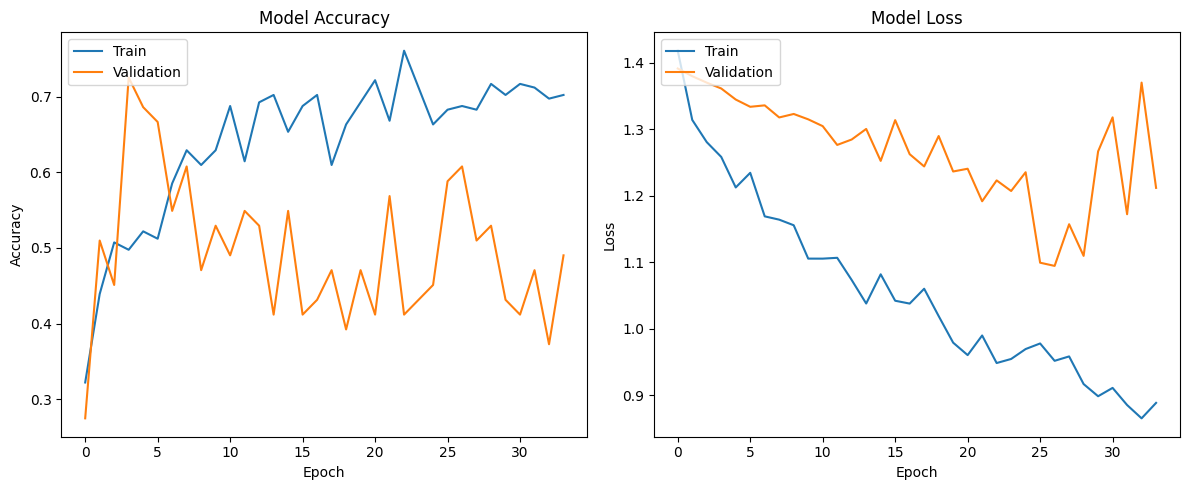

In [63]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_conv.history['accuracy'])
plt.plot(history_conv.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_conv.history['loss'])
plt.plot(history_conv.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


In [64]:
modelo_conv.evaluate(x_train, y_train)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6641 - loss: 1.3579  


[1.3579368591308594, 0.6640625]

In [65]:
modelo_conv.evaluate(x_val, y_val)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - accuracy: 0.5176 - loss: 1.3609


[1.3608843088150024, 0.5176470875740051]

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step


precision    recall  f1-score   support

           0       0.21      0.35      0.26        20
           1       1.00      0.29      0.44        21
           2       0.42      0.38      0.40        21
           3       0.88      1.00      0.94        23

    accuracy                           0.52        85
   macro avg       0.63      0.50      0.51        85
weighted avg       0.64      0.52      0.52        85

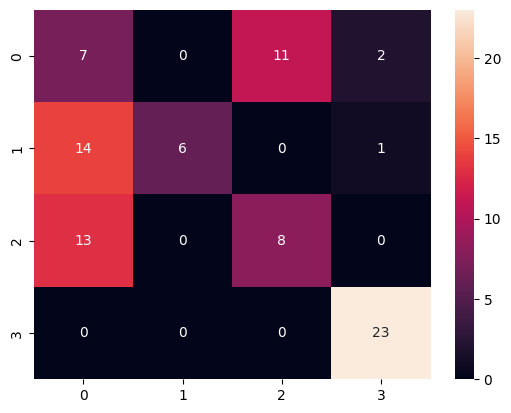

In [66]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

y_predict = modelo_conv.predict(x_val)

y_test_class = np.argmax(y_val,axis=1)
y_pred_class = np.argmax(y_predict,axis=1)

#Accuracy of the predicted values
console.print(classification_report(y_test_class, y_pred_class))
cm = confusion_matrix(y_test_class, y_pred_class)

# visualize the confusion matrix in a heat map
df_cm = pd.DataFrame(cm)
heatmap = sns.heatmap(df_cm, annot=True, fmt="d")

### **Conclusions:**

- The current accuracy (~52%) reflects that the network is now attempting to learn actual features rather than just memorizing samples.

- Class Sensitivity: There is a significant disparity in performance across classes. While Class 3 shows excellent metrics (F1-score of 0.94), Class 1 suffers from very low recall (0.29), meaning the model is missing most of its instances.

- Confusion Patterns: This suggests that the acoustic features of these three classes might overlap significantly in the current spectrogram representation.

- Recommendation: create a new dataset with absolutely different sounds.

## **MFCC - Mel-Frequency Cepstral Coefficients**

### **Extract MFCC**

In [160]:
def add_white_noise(signal, noise_factor=0.0005):
    noise = np.random.randn(len(signal))
    augmented_signal = signal + noise_factor * noise
    return augmented_signal

In [161]:
import librosa
import numpy as np
import os

def extract_mfcc_with_deltas(file_path, n_mfcc=20, max_len=100, augment=False):

    signal, sr = librosa.load(file_path, sr=22050)

    if augment:
        signal = add_white_noise(signal)

    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)

    delta_mfcc = librosa.feature.delta(mfcc)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)

    combined = np.concatenate((mfcc, delta_mfcc, delta2_mfcc), axis=0)

    if combined.shape[1] < max_len:
        pad_width = max_len - combined.shape[1]
        combined = np.pad(combined, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        combined = combined[:, :max_len]

    return combined

In [162]:
import os

directory = '/content/sounds-classification-export/training/'
files = os.listdir(directory)
files.sort()

wav_files = [f for f in files if f.endswith('.wav')]
number_files = len(wav_files)
console.print(number_files)

x_data = []
y_labels_expanded = []

for index, file_name in enumerate(wav_files):
  file_path=directory + file_name

  mfcc_features = extract_mfcc_with_deltas(file_path, augment=False)
  x_data.append(mfcc_features)
  y_labels_expanded.append(y_train[index])

  features_noise = extract_mfcc_with_deltas(file_path, augment=True)
  x_data.append(features_noise)
  y_labels_expanded.append(y_train[index])

x_train_tmp = np.array(x_data)
x_train_tmp = np.transpose(x_train_tmp, (0, 2, 1))

x_train = tf.convert_to_tensor(x_train_tmp, dtype=tf.float32)

console.print(x_train.shape)

256

(512, 100, 60)

In [165]:
full_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_labels_expanded))
full_dataset = full_dataset.shuffle(buffer_size=512)

size = x_train.shape[0]

val_size = int(0.2 * size)
train_size = size - val_size

train_ds = full_dataset.take(train_size).batch(32)
val_ds = full_dataset.skip(train_size).batch(32)

In [166]:
import os

directory = '/content/sounds-classification-export/testing/'
files = os.listdir(directory)
files.sort()

wav_files = [f for f in files if f.endswith('.wav')]
number_files = len(wav_files)
console.print(number_files)

x_data_val = []

for index, file_name in enumerate(wav_files):
  file_path=directory + file_name
  mfcc_features = extract_mfcc_with_deltas(file_path)
  x_data_val.append(mfcc_features)

x_val_tmp = np.array(x_data_val)
x_val_tmp = np.transpose(x_val_tmp, (0, 2, 1))

x_val = tf.convert_to_tensor(x_val_tmp, dtype=tf.float32)

console.print(x_val.shape)

85

(85, 100, 60)

### **RNN LSTM**

In [167]:
from tensorflow.keras import layers, models

modelo_rnn = models.Sequential([
    layers.Input(shape=(100, 60)),

    layers.BatchNormalization(),

    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),

    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

modelo_rnn.summary()

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_24          │ (None, 100, 60)        │           240 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_47 (LSTM)                  │ (None, 100, 64)        │        32,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_48 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,788 (174.95 KB)

 Trainable params: 44,668 (174.48 KB)

 Non-trainable params: 120 (480.00 B)

In [168]:
import tensorflow

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

modelo_rnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stopping = tensorflow.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=30,
    verbose=1,
    restore_best_weights=True
)

history_rnn = modelo_rnn.fit(train_ds, validation_data=val_ds, epochs=100, callbacks=[early_stopping, lr_scheduler])

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.2561 - loss: 1.3983 - val_accuracy: 0.3431 - val_loss: 1.3819 - learning_rate: 0.0010
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2366 - loss: 1.3911 - val_accuracy: 0.2647 - val_loss: 1.3851 - learning_rate: 0.0010
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2659 - loss: 1.3845 - val_accuracy: 0.2745 - val_loss: 1.3834 - learning_rate: 0.0010
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2951 - loss: 1.3755 - val_accuracy: 0.2745 - val_loss: 1.3858 - learning_rate: 0.0010
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2780 - loss: 1.3888 - val_accuracy: 0.2549 - val_loss: 1.3880 - learning_rate: 0.0010
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2902 - loss: 1.3725 - val_accuracy: 0.3137 - val_loss: 1.3826 - learning_rate: 0.0010
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2878 - loss: 1.3741 - 

### **Validation**

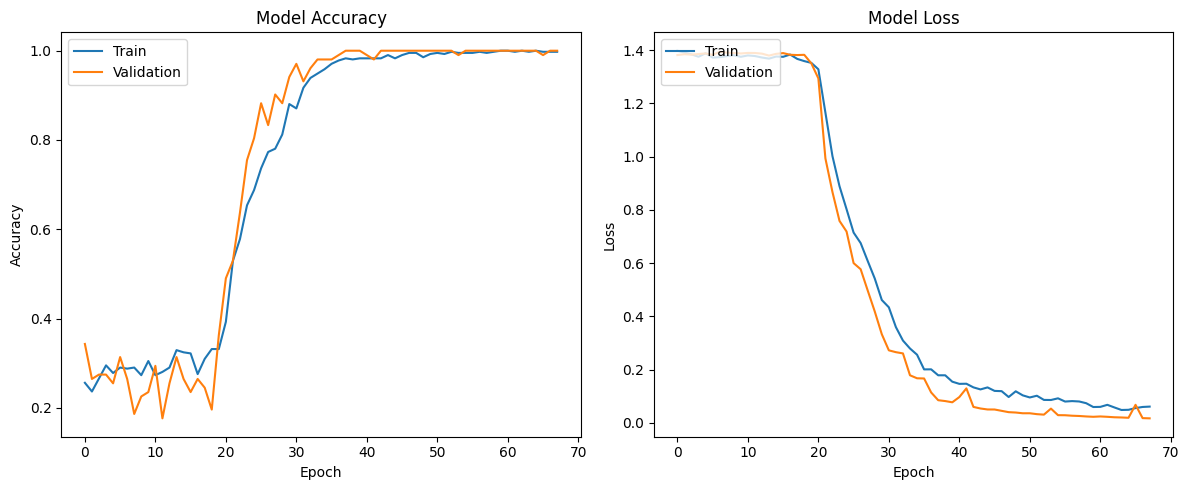

In [169]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['accuracy'])
plt.plot(history_rnn.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['loss'])
plt.plot(history_rnn.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


In [174]:
modelo_rnn.evaluate(x_val, y_val)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7412 - loss: 0.8431


[0.8431183695793152, 0.7411764860153198]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


precision    recall  f1-score   support

           0       0.76      0.65      0.70        20
           1       0.71      0.57      0.63        21
           2       0.58      0.71      0.64        21
           3       0.92      1.00      0.96        23

    accuracy                           0.74        85
   macro avg       0.74      0.73      0.73        85
weighted avg       0.75      0.74      0.74        85

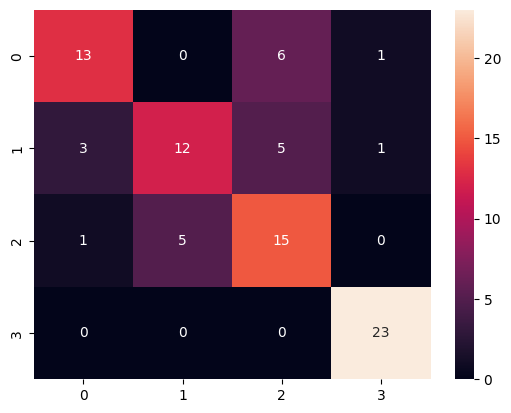

In [175]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

y_predict = modelo_rnn.predict(x_val)

y_test_class = np.argmax(y_val,axis=1)
y_pred_class = np.argmax(y_predict,axis=1)

#Accuracy of the predicted values
console.print(classification_report(y_test_class, y_pred_class))
cm = confusion_matrix(y_test_class, y_pred_class)

# visualize the confusion matrix in a heat map
df_cm = pd.DataFrame(cm)
heatmap = sns.heatmap(df_cm, annot=True, fmt="d")

### **Summary of the Process: MFCC & RNN**
- Feature Extraction (MFCC + Deltas): Instead of raw spectrograms, we switched to Mel-Frequency Cepstral Coefficients (MFCC). We also added Delta and Delta-Delta features, giving the model 60 characteristics per time step. This allowed the network to understand how the sound changes over that 1-second duration.

- Architecture (LSTM): We moved from a 2D Convolutional approach to a Recurrent Neural Network using LSTM layers. This was crucial because audio is sequential; the LSTM "remembers" the beginning of the sound to better classify its end.

- Optimization: We implemented BatchNormalization to stabilize the diverse scales of the MFCC data and used a Learning Rate Scheduler (ReduceLROnPlateau) to fine-tune the learning process.

- Data Augmentation: To tackle the confusion between classes, we added White Noise and doubled the training data, providing the model with both perfect and "real-world" versions of each sound.


### **Conclusions:**

- Class Discrimination: The model shows exceptional performance on Class 3 (0.96 F1-score), indicating that this category has unique temporal or spectral signatures that the LSTM captures easily.

- Sequential Learning: The transition to an RNN architecture was successful. The model is now capable of processing the 1-second duration as a cohesive sequence rather than a static image.

- Generalization vs. Overfitting: By introducing noise and normalization, we successfully broke the "100% training accuracy" trap. The current 74% accuracy represents real learning that is more likely to work on new, unseen recordings.

- Identified Weakness: There is still significant confusion between Classes 0, 1, and 2. Specifically, Class 2 has a lower precision (0.58), often being mistaken for Classes 0 and 1. This suggests these three sounds share very similar frequency profiles.